In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "BCCD Dataset with mask/test/original/e3ea07d7-884a-412e-874a-40fd6b856736.png"

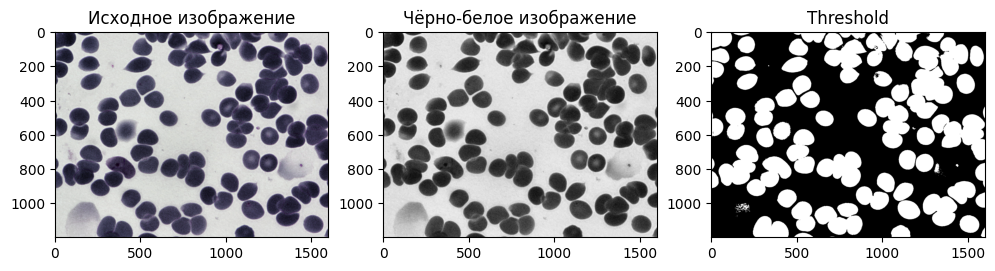

In [2]:
img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

_, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Исходное изображение")

axes[1].imshow(gray_img, cmap="gray")
axes[1].set_title("Чёрно-белое изображение")

axes[2].imshow(thresh, cmap="gray")
axes[2].set_title("Threshold")
plt.show()

In [3]:
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel, iterations = 2)

sure_bg = cv2.dilate(opening,kernel,iterations=3)

dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2, 3)
ret, sure_fg = cv2.threshold(dist_transform,0.1*dist_transform.max(),255,0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

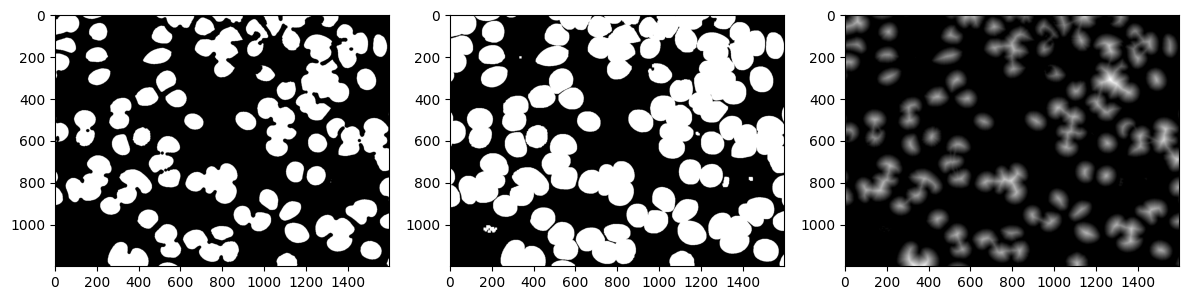

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(sure_fg, cmap="gray")

axes[1].imshow(sure_bg, cmap="gray")

axes[2].imshow(dist_transform, cmap="gray")

plt.tight_layout()
plt.show()

Клеток: 65


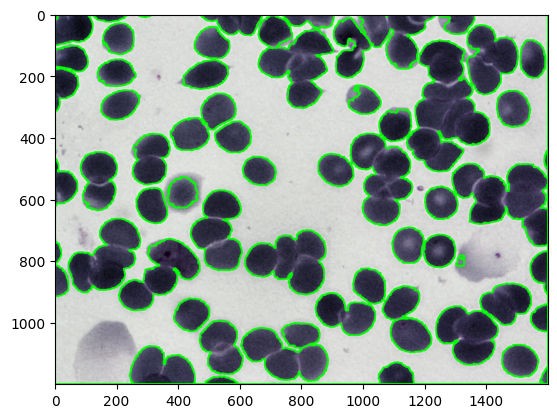

In [5]:
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

unique_markers = np.unique(markers)
print(f"Клеток: {len(unique_markers) - 3}")

border_mask = (markers == -1).astype(np.uint8) * 255

kernel_thick = np.ones((3, 3), np.uint8)
border_mask_thick = cv2.dilate(border_mask, kernel_thick, iterations=2)

img[border_mask_thick == 255] = [0, 255, 0]

plt.imshow(img)
plt.show()

Клеток: 65


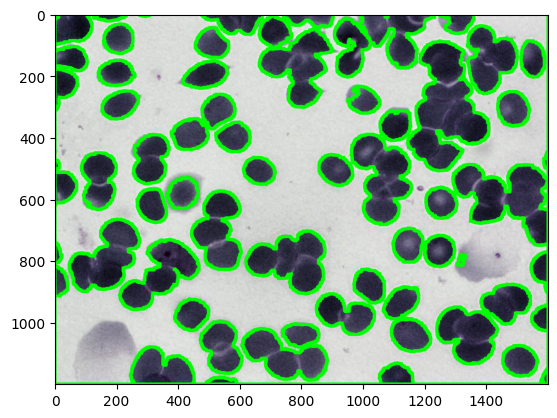

In [6]:
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

unique_markers = np.unique(markers)
print(f"Клеток: {len(unique_markers) - 3}")

border_mask = (markers == -1).astype(np.uint8) * 255

kernel_thick = np.ones((5, 5), np.uint8)
border_mask_thick = cv2.dilate(border_mask, kernel_thick, iterations=2)

img[border_mask_thick == 255] = [0, 255, 0]

plt.imshow(img)
plt.show()

Клеток: 65


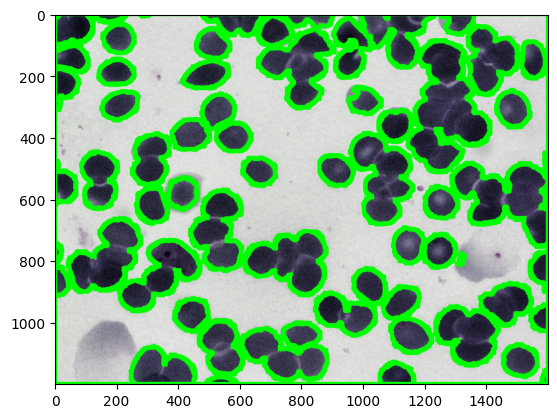

In [7]:
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

unique_markers = np.unique(markers)
print(f"Клеток: {len(unique_markers) - 3}")

border_mask = (markers == -1).astype(np.uint8) * 255

kernel_thick = np.ones((7, 7), np.uint8)
border_mask_thick = cv2.dilate(border_mask, kernel_thick, iterations=2)

img[border_mask_thick == 255] = [0, 255, 0]

plt.imshow(img)
plt.show()